In [6]:
import sys
print(sys.executable)


c:\venvs\fintech\Scripts\python.exe


# Agentic system

In [3]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_percentage_error, mean_absolute_error
import numpy as np
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from langchain.tools import tool
import shap
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder
from langchain_classic.agents import create_tool_calling_agent, AgentExecutor
from pathlib import Path
from pydantic import BaseModel, Field
from typing import Optional
import re

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import json

from langchain_community.document_loaders import Docx2txtLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_ollama import ChatOllama

c:\venvs\fintech\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "llama3.1:8b "
# "llama3.1:latest" 

llm = ChatOllama(
    model=MODEL,
    temperature=0
)

In [37]:
def build_rag_retriever(docx_path: str, chunk_size: int = 800, chunk_overlap: int = 100):
    loader   = Docx2txtLoader(docx_path)
    docs     = loader.load()
    splitter = RecursiveCharacterTextSplitter(
        chunk_size    = chunk_size,
        chunk_overlap = chunk_overlap,
        separators    = ["\n\n", "\n", " "]
    )
    chunks = splitter.split_documents(docs)
    
    # Free local embeddings — no API key needed
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        model_kwargs={"device": "cpu"},   # change to "cuda" if you have a GPU
        encode_kwargs={"normalize_embeddings": True}
    )
    
    vectorstore = FAISS.from_documents(chunks, embeddings)
    print(f"RAG index built: {len(chunks)} chunks from {docx_path}")
    return vectorstore.as_retriever(search_kwargs={"k": 6})

def retrieve_schema_context(prompt: str, RAG_RETRIEVER) -> str:
    docs = RAG_RETRIEVER.invoke(prompt)
    return "\n\n---\n\n".join(d.page_content for d in docs)

### Read data tool Code base

In [38]:
@tool
def read_data_tool(csv_path: str, prompt: str) -> dict:
    """
    Reads the CSV at csv_path (first 3 rows for schema inspection).
    Returns column names, dtypes, sample values, and the user prompt
    so the agent can classify columns. NO data transformations are done here.
    """
    df = pd.read_csv(csv_path, nrows=3)
    cols = df.columns.tolist()
    dtypes = df.dtypes.astype(str).to_dict()
    sample = df.head(2).to_dict(orient="records")
    return {
        "all_columns": cols,
        "dtypes":      dtypes,
        "sample_rows": sample,
        "prompt":      prompt,
        "csv_path":    csv_path
    }

@tool
def retrieve_rag_context_tool(prompt: str) -> str:
    """
    Retrieves dataset-related knowledge from the RAG knowledge base
    using the user's prediction prompt as the query.

    Returns relevant text about target derivation, feature engineering
    rules, and expected column classifications for the matched dataset type.
    Use this BEFORE classifying columns.
    """
    RAG_RETRIEVER = build_rag_retriever("RAG_for_readdataset_agent.docx")
    return retrieve_schema_context(prompt, RAG_RETRIEVER)


READ_DATA_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """
You are a data schema classification agent. Your ONLY job is to inspect
the dataset structure and classify columns. You do NOT perform any data
transformations, feature engineering, or target derivation.

Steps:
1. Call read_data_tool with the csv_path and prompt to get column names,
   dtypes, and sample rows.
2. Call retrieve_rag_context_tool with the prompt to fetch schema rules
   from the knowledge base.
3. Using the RAG context and column metadata, classify every column as:
   - target        : the single column to predict. If it must be derived
                     (e.g. volatility from Close, gdp_growth from gdp),
                     set derivation_required=true and name the derived column.
   - feature_columns: columns that will be used as predictors AFTER
                      engineering (list the raw names that exist now;
                      the preprocessing agent will create lags/rolls).
   - date_columns  : date/time identifier columns — never used as features.
   - drop_columns  : columns to discard entirely (ids, duplicates, etc.).

Rules:
- Do NOT compute anything — only classify what already exists in the CSV.
- If derivation is needed, describe WHAT to derive, not HOW.
- Follow the RAG context for dataset-specific classification rules.

Return ONLY a JSON dict inside a ```json ... ``` block:
{{
  "csv_path":           "original csv path",
  "target":             "column_name_or_derived_name",
  "feature_columns":    ["raw_col1", "raw_col2", ...],
  "date_columns":       ["date_col"],
  "drop_columns":       ["col_to_drop", ...],
  "derivation_required": true | false,
  "dataset_type":       "cpi" | "gdp" | "volatility" | "generic",
  "notes":              "any important notes about the schema"
}}
"""),
    ("human", "CSV path: {csv_path}\nPrediction goal: {prompt}"),
    ("placeholder", "{agent_scratchpad}")
])

In [39]:
def build_read_data_agent(temperature: float = 0):
    llm   = ChatOllama(model=MODEL, temperature=temperature)
    tools = [read_data_tool, retrieve_rag_context_tool]   # derive_target removed
    agent = create_tool_calling_agent(llm, tools, READ_DATA_PROMPT)
    return AgentExecutor(
        agent=agent,
        tools=tools,
        verbose=True,
        return_intermediate_steps=True,
        max_iterations=5
    )


READ_DATA_AGENT = build_read_data_agent()

### tests

In [ ]:
#cpi
csv_path = 'H:/Projects/Fintech agent/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv'
# 'D:/Internship/Fintech-agent/data/macro/combined_macro_data.csv'
prompt = 'with the given dataset predict future inflation rate'
read_result = READ_DATA_AGENT.invoke({
    "csv_path": csv_path,
    "prompt":   prompt
})
print(read_result)



> Entering new AgentExecutor chain...

Invoking: `read_data_tool` with `{'csv_path': 'H:/Projects/Fintech agent/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv', 'prompt': 'with the given dataset predict future inflation rate'}`


{'all_columns': ['date', 'b30ret', 'b20ret', 'b10ret', 'b7ret', 'b5ret', 'b2ret', 'b1ret', 't90ret', 't30ret', 'cpiret', 'wti_price', 'fedfunds', 'nfci', 'anfci', 'nfci_risk', 'nfci_credit', 'nfci_leverage', 'nfci_nonfinancial_leverage', 'gdp', 'gdp_growth', 'ppi', 'trade_balance', 'unrate', 'usd_index'], 'dtypes': {'date': 'str', 'b30ret': 'float64', 'b20ret': 'float64', 'b10ret': 'float64', 'b7ret': 'float64', 'b5ret': 'float64', 'b2ret': 'float64', 'b1ret': 'float64', 't90ret': 'float64', 't30ret': 'float64', 'cpiret': 'float64', 'wti_price': 'float64', 'fedfunds': 'float64', 'nfci': 'float64', 'anfci': 'float64', 'nfci_risk': 'float64', 'nfci_credit': 'float64', 'nfci_leverage': 'float64', 'nfci_nonfinancial_leverage': 'float64', 'gdp':

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5882.93it/s]


RAG index built: 8 chunks from RAG_for_readdataset_agent.docx
RAG Knowledge Base: Dataset Schema & Target Derivation

1. Dataset: CPI (Inflation)

1.1 Description

CPI forecasting predicts quarterly inflation as measured by the return on the Consumer Price Index (cpiret). The target is a continuous percentage change series. It is typically already present as a raw column named cpiret.

1.2 Trigger Keywords

Match this dataset type when the user prompt contains any of:

'predict CPI', 'forecast inflation', 'predict cpiret', 'CPI return', 'consumer price index', 'inflation forecasting'

1.3 Target Derivation

The target column cpiret is expected to already exist in the dataset. No computation required. If it is missing but a raw CPI level column exists (e.g. 'CPI' or 'cpi_level'), compute:

df['cpiret'] = df['cpi_level'].pct_change()

---

df['cpiret'] = df['cpi_level'].pct_change()

Then drop the raw level column from features.

1.4 Feature Engineering Rules

Create lagged target: cpire

In [ ]:
#gdp
csv_path = 'H:/Projects/Fintech agent/Forecasting-Agent-for-Fintech/data/macro/GDP_dataset.csv'
prompt = 'forecast upcoming quarters GDP using the given dataset'
read_result = READ_DATA_AGENT.invoke({
    "csv_path": csv_path,
    "prompt":   prompt
})
print(read_result)

In [ ]:
# volatility
csv_path = 'H:/Projects/Fintech agent/Forecasting-Agent-for-Fintech/data/macro/volatility_dataset_daily.csv'
prompt = 'forecast volaitlity'
read_result = READ_DATA_AGENT.invoke({
    "csv_path": csv_path,
    "prompt":   prompt
})
print(read_result)

## preprocess agent

In [18]:
OUTPUT_DIR = "D:/mycode/Fintech-agent/data/processed_data"

@tool
def preprocess_tool(csv_path: str,
    target_col:         str,
    date_col:           str,
    feature_cols:       list,
    drop_cols:          list,
    target_lags:        list,        # e.g. [1,2,3,4] or [1,2,3,5,10]
    target_rolls:       list,        # e.g. [2,4] or [5,10,21]
    feature_lag:        int,         # how many lags to create for exog features (usually 1)
    derive_target:      bool,        # True if target must be computed from raw cols
    derive_config:      dict,        # instructions for derivation — see notes below
    test_size:          int,         # rows to hold out
    freq:               str,         # 'daily', 'monthly', 'quarterly', 'annual'
) -> dict:
    """
    Single unified preprocessing pipeline for any dataset.

    derive_config keys (all optional, used only when derive_target=True):
      - method       : 'pct_change' | 'log_return' | 'rolling_std_log_return'
      - source_col   : column to derive the target from (e.g. 'Close', 'gdp', 'cpi_level')
      - window       : rolling window size (used by rolling_std_log_return, e.g. 21)
      - annualise    : bool — multiply std by sqrt(252) (volatility only)
      - scale        : float multiplier applied after derivation (e.g. 100 for gdp %)
      - extra_cols   : list of extra engineered columns to build from raw price/volume
                       cols before dropping them, e.g.:
                       [
                         {"name":"daily_range",   "expr":"(High-Low)/Close"},
                         {"name":"volume_change",  "expr":"Volume.pct_change()"},
                         {"name":"close_lag1",     "expr":"Close.shift(1)"},
                         {"name":"return_lag1",    "expr":"log_return.shift(1)"}
                       ]
      - drop_after   : list of raw cols to drop after derivation
                       (e.g. ['Close','Open','High','Low','Volume','log_return'])

    Returns file paths + metadata for the forecasting agent.
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    df = pd.read_csv(csv_path)

    # normalise date column name
    for col in df.columns:
        if col.lower() in ("date", "dates"):
            df.rename(columns={col: date_col}, inplace=True)
            break

    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df.sort_values(date_col, inplace=True)
        df.reset_index(drop=True, inplace=True)

    if derive_target and derive_config:
        method     = derive_config.get("method", "pct_change")
        source_col = derive_config.get("source_col", "")
        window     = int(derive_config.get("window", 21))
        annualise  = derive_config.get("annualise", False)
        scale      = float(derive_config.get("scale", 1.0))
        extra_cols = derive_config.get("extra_cols", [])
        drop_after = derive_config.get("drop_after", [])

        if method == "pct_change":
            df[target_col] = df[source_col].pct_change() * scale

        elif method == "log_return":
            df["log_return"] = np.log(df[source_col] / df[source_col].shift(1))
            df[target_col]   = df["log_return"] * scale

        elif method == "rolling_std_log_return":
            df["log_return"] = np.log(df[source_col] / df[source_col].shift(1))
            rolled = df["log_return"].shift(1).rolling(window).std()
            df[target_col] = rolled * (np.sqrt(252) if annualise else 1.0)
            df.dropna(subset=[target_col], inplace=True)

        else:
            raise ValueError(f"Unknown derive method: {method}")

        # build any extra engineered columns (e.g. daily_range, volume_change)
        for ec in extra_cols:
            name = ec["name"]
            expr = ec["expr"]
            # safe eval with df columns available as local names
            local_ns = {c: df[c] for c in df.columns if c in expr}
            local_ns["np"] = np
            df[name] = eval(expr, {"__builtins__": {}}, local_ns)

        # drop raw source columns that should not be features
        df.drop(columns=[c for c in drop_after if c in df.columns], inplace=True)
    
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    df.dropna(subset=[target_col], inplace=True)
    df.reset_index(drop=True, inplace=True)

    #    (prevents look-ahead; exog cols are replaced by their lagged version)
    exog_cols = [c for c in feature_cols if c in df.columns and c != target_col]
    for col in exog_cols:
        df[f"{col}_lag{feature_lag}"] = df[col].shift(feature_lag)
        df.drop(columns=[col], inplace=True)

    for lag in target_lags:
        df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    for w in target_rolls:
        df[f"{target_col}_roll{w}"] = df[target_col].shift(1).rolling(w).mean()

    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    if date_col in df.columns:
        dates = df[date_col].copy()
        df.drop(columns=[date_col], inplace=True)
    else:
        dates = pd.Series(range(len(df)), name="index")
    if len(df) <= test_size:
        raise ValueError(
            f"Dataset too small ({len(df)} rows) for test_size={test_size}"
        )

    train_df = df.iloc[:-test_size].copy()
    test_df  = df.iloc[-test_size:].copy()

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col]
    test_dates = dates.iloc[-test_size:].reset_index(drop=True)

    paths = {
        "X_train":    os.path.join(OUTPUT_DIR, "X_train.csv"),
        "X_test":     os.path.join(OUTPUT_DIR, "X_test.csv"),
        "y_train":    os.path.join(OUTPUT_DIR, "y_train.csv"),
        "y_test":     os.path.join(OUTPUT_DIR, "y_test.csv"),
        "test_dates": os.path.join(OUTPUT_DIR, "test_dates.csv"),
    }
    X_train.to_csv(paths["X_train"],       index=False)
    X_test.to_csv( paths["X_test"],        index=False)
    y_train.to_csv(paths["y_train"],       index=False)
    y_test.to_csv( paths["y_test"],        index=False)
    test_dates.to_csv(paths["test_dates"], index=False, header=True)

    return {
        "file_paths":      paths,
        "target_col":      target_col,
        "feature_columns": X_train.columns.tolist(),
        "train_rows":      len(X_train),
        "test_rows":       len(X_test),
        "freq":            freq,
    }


PREPROCESS_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """
You are a data preprocessing agent. You receive a schema summary from the
read-data agent and must call preprocess_tool with the correct dynamic
parameters. You decide ALL numeric and structural parameters yourself
based on the schema metadata — do not use hardcoded defaults.

PARAMETER DECISION RULES 

freq  →  infer from dataset_type or date pattern:
         'daily' | 'monthly' | 'quarterly' | 'annual'

test_size  →  based on freq:
              daily      → 21   (≈ 1 trading month)
              monthly    → 12   (1 year)
              quarterly  → 8    (2 years)
              annual     → 3

target_lags  →  based on freq:
                daily      → [1, 2, 3, 5, 10]
                monthly    → [1, 2, 3, 6, 12]
                quarterly  → [1, 2, 4]
                annual     → [1, 2]

target_rolls  →  based on freq:
                 daily      → [5, 10, 21]
                 monthly    → [3, 6, 12]
                 quarterly  → [2, 4, 8]
                 annual     → [2, 3]

feature_lag  →  almost always 1 (lag exogenous/macro features by 1 period
                to avoid look-ahead bias). Use 2 only if schema notes warn
                about reporting delays.

derive_target  →  true only if the target column does not exist in the raw
                  CSV and must be computed (e.g. volatility from Close,
                  gdp_growth from gdp, cpiret from cpi_level).
                  false if the target column already exists.

derive_config  →  build from schema notes:
  method:
    'pct_change'              → target = source_col.pct_change() * scale
    'log_return'              → target = log(source/source.shift(1))
    'rolling_std_log_return'  → volatility = rolling std of log returns

  Examples:
    GDP growth from gdp column:
      {{"method":"pct_change","source_col":"gdp","scale":100,"drop_after":["gdp"]}}

    CPI return from cpi_level:
      {{"method":"pct_change","source_col":"cpi_level","scale":1,"drop_after":["cpi_level"]}}

    Volatility from OHLCV:
      {{
        "method":      "rolling_std_log_return",
        "source_col":  "Close",
        "window":      21,
        "annualise":   true,
        "drop_after":  ["Close","Open","High","Low","Volume","log_return"],
        "extra_cols":  [
          {{"name":"daily_range",  "expr":"(High-Low)/Close"}},
          {{"name":"volume_change","expr":"Volume.pct_change()"}},
          {{"name":"close_lag1",   "expr":"Close.shift(1)"}},
          {{"name":"return_lag1",  "expr":"log_return.shift(1)"}}
        ]
      }}

CALL preprocess_tool with all parameters
After the tool returns, pass back the complete output unchanged so the
forecasting agent receives file_paths, target_col, and feature_columns.
"""),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])


def build_preprocess_agent(temperature: float = 0):
    llm   = ChatOllama(model=MODEL, temperature=temperature)
    tools = [preprocess_tool]
    agent = create_tool_calling_agent(llm, tools, PREPROCESS_PROMPT)
    return AgentExecutor(
        agent=agent,
        tools=tools,
        verbose=True,
        return_intermediate_steps=True,
        max_iterations=4
    )


PREPROCESS_AGENT = build_preprocess_agent()

In [24]:
output = read_result["output"]
start = output.find("{")
end = output.rfind("}")
if start == -1 or end == -1:
    raise ValueError("Read-data agent did not return a JSON object")
json_text = output[start:end + 1]
try:
    schema = json.loads(json_text)
except json.JSONDecodeError as e:
    raise ValueError(
        f"Invalid JSON returned by read-data agent: {e}\n"
        f"Extracted JSON:\n{json_text}"
    )

In [25]:
schema

{'csv_path': 'H:/Projects/Fintech agent/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv',
 'target': 'cpiret',
 'feature_columns': ['b30ret',
  'b20ret',
  'b10ret',
  'b7ret',
  'b5ret',
  'b2ret',
  'b1ret',
  't90ret',
  't30ret',
  'wti_price',
  'fedfunds',
  'nfci',
  'anfci',
  'nfci_risk',
  'nfci_credit',
  'nfci_leverage',
  'nfci_nonfinancial_leverage',
  'gdp_growth',
  'ppi',
  'trade_balance',
  'unrate',
  'usd_index'],
 'date_columns': ['date'],
 'drop_columns': ['b30ret_lag1',
  'b20ret_lag1',
  'b10ret_lag1',
  'b7ret_lag1',
  'b5ret_lag1',
  'b2ret_lag1',
  'b1ret_lag1',
  't90ret_lag1',
  't30ret_lag1'],
 'derivation_required': False,
 'dataset_type': 'cpi',
 'notes': ''}

In [26]:
# ── Step 2: preprocessing — LLM decides all dynamic values ────────────
preprocess_input = f"""
Schema from read-data agent:
{json.dumps(schema, indent=2)}

Original CSV path : {schema['csv_path']}
Prediction goal   : {prompt}

Use the schema above to decide all preprocessing parameters and call
preprocess_tool. Follow the parameter decision rules in your system prompt.
"""

preprocess_result = PREPROCESS_AGENT.invoke({"input": preprocess_input})



> Entering new AgentExecutor chain...
{"name": "preprocess_tool", "parameters": {"csv_path": "H:/Projects/Fintech agent/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv", "target_col": "cpiret", "date_col": "date", "feature_cols": ["b30ret", "b20ret", "b10ret", "b7ret", "b5ret", "b2ret", "b1ret", "t90ret", "t30ret", "wti_price", "fedfunds", "nfci", "anfci", "nfci_risk", "nfci_credit", "nfci_leverage", "nfci_nonfinancial_leverage", "gdp_growth", "ppi", "trade_balance", "unrate", "usd_index"], "drop_cols": ["b30ret_lag1", "b20ret_lag1", "b10ret_lag1", "b7ret_lag1", "b5ret_lag1", "b2ret_lag1", "b1ret_lag1", "t90ret_lag1", "t30ret_lag1"], "target_lags": [1, 2, 3, 6, 12], "target_rolls": [5, 10, 21], "feature_lag": 1, "derive_target": False, "derive_config": {}, "test_size": 12, "freq": "monthly"}}

> Finished chain.


In [27]:
def escape(text: str) -> str:
        #Escape all curly braces except LangChain placeholders.
        return text.replace("{", "{{").replace("}", "}}")

### Forecasting tool and codebase

In [28]:
MODEL_REGISTRY = {
    "xgb":   lambda cfg: XGBRegressor(
                 n_estimators    = cfg.get("n_estimators",    500),
                 learning_rate   = cfg.get("learning_rate",   0.03),
                 max_depth       = cfg.get("max_depth",        3),
                 subsample       = cfg.get("subsample",        0.8),
                 colsample_bytree= cfg.get("colsample_bytree", 0.8),
                 reg_lambda      = cfg.get("reg_lambda",       1.0),
                 reg_alpha       = cfg.get("reg_alpha",        0.0),
                 min_child_weight= cfg.get("min_child_weight", 1),
                 objective="reg:squarederror", verbosity=0,
                 n_jobs=-1, random_state=42),
    "gbr":   lambda cfg: GradientBoostingRegressor(
                 n_estimators    = cfg.get("n_estimators",    300),
                 learning_rate   = cfg.get("learning_rate",   0.05),
                 max_depth       = cfg.get("max_depth",        3),
                 subsample       = cfg.get("subsample",        0.8),
                 min_samples_leaf= cfg.get("min_samples_leaf", 3),
                 min_samples_split=cfg.get("min_samples_split",2),
                 random_state=42),
    "svr":   lambda cfg: SVR(
                 C       = cfg.get("C",       10.0),
                 epsilon = cfg.get("epsilon",  0.01),
                 gamma   = cfg.get("gamma",   "scale"),
                 kernel  = cfg.get("kernel",  "rbf")),
    "bayes": lambda cfg: BayesianRidge(),
    "knn":   lambda cfg: KNeighborsRegressor(
                 n_neighbors = cfg.get("n_neighbors", 7),
                 weights     = cfg.get("weights",    "distance"),
                 metric      = cfg.get("metric",     "euclidean"),
                 n_jobs=-1),
}

HYPERPARAM_REFERENCE = """
VALID HYPERPARAMETERS PER MODEL:

svr:
  C:        float, 0.01-1000.0    
  epsilon:  float, 0.0001-1.0     
  gamma:    'scale' or 0.001-10.0 
  kernel:   'rbf' or 'linear'

knn:
  n_neighbors: int, 3-30         
  weights:     'uniform' or 'distance'
  metric:      'euclidean' or 'manhattan'

xgb:
  n_estimators:    int, 400-600  
  learning_rate:   float, 0.01-0.05 
  max_depth:       int, 2-4       
  subsample:       float, 0.5-1.0 
  colsample_bytree:float, 0.5-1.0  
  reg_lambda:      float, 0.1-10.0
  reg_alpha:       float, 0.0-1.0  

gbr:
  n_estimators:    int, 100-1000
  learning_rate:   float, 0.001-0.2
  max_depth:       int, 2-6
  subsample:       float, 0.5-1.0
  min_samples_leaf:int, 1-20     
  min_samples_split:int, 2-20
"""
PARAM_BOUNDS = {
    "n_estimators":      (50, 1000, int),
    "max_depth":         (1, 10, int),
    "learning_rate":     (0.001, 0.5, float),
    "subsample":         (0.1, 1.0, float),
    "colsample_bytree":  (0.1, 1.0, float),
    "reg_lambda":        (0.0, 20.0, float),
    "reg_alpha":         (0.0, 10.0, float),
    "min_child_weight":  (1, 20, int),
    "gamma":             (0.0, 5.0, float),
    "min_samples_leaf":  (1, 50, int),
    "min_samples_split": (2, 50, int),
    "C":                 (0.001, 1000.0, float),
    "epsilon":           (0.0001, 1.0, float),
    "n_neighbors":       (1, 50, int),
}

def clamp_params(params: dict) -> dict:
    """
    Clamp every numeric hyperparameter to its valid range.
    Prevents InvalidParameterError (e.g. subsample=1.05) regardless
    of what the LLM suggests.
    """
    cleaned = {}
    for k, v in params.items():
        if k in PARAM_BOUNDS:
            lo, hi, typ = PARAM_BOUNDS[k]
            if isinstance(v, (int, float)):
                v = max(lo, min(hi, v))
                v = typ(v)
            cleaned[k] = v
        else:
            cleaned[k] = v  # categorical params (kernel, weights, metric) pass through
    return cleaned

In [29]:
def forecast(data_paths, model_name, model_params):
    X_train = pd.read_csv(data_paths["X_train"])
    X_test  = pd.read_csv(data_paths["X_test"])
    y_train = pd.read_csv(data_paths["y_train"]).squeeze()
    y_test  = pd.read_csv(data_paths["y_test"]).squeeze()
 
    model = MODEL_REGISTRY[model_name](model_params)
    model.fit(X_train, y_train)
 
    y_train_pred = model.predict(X_train)
 
    X_test_recursive  = X_test.copy()
    predictions       = []
    prediction_history = list(y_train.values)  # real history for rolling computation
 
    for i in range(len(X_test)):
        row  = X_test_recursive.iloc[[i]].copy()
        pred = model.predict(row)[0]
        predictions.append(pred)
        prediction_history.append(pred)
 
        for lag in [1, 2, 4]:
            col = f"cpiret_lag{lag}"
            if col in X_test_recursive.columns:
                future_idx = i + lag
                if future_idx < len(X_test_recursive):
                    X_test_recursive.at[
                        X_test_recursive.index[future_idx], col] = pred
 
        for w in [2, 4]:
            col = f"cpiret_roll{w}"
            if col in X_test_recursive.columns:
                next_idx = i + 1
                if next_idx < len(X_test_recursive):
                    roll_val = np.mean(prediction_history[-w:])
                    X_test_recursive.at[
                        X_test_recursive.index[next_idx], col] = roll_val
 
    predictions = np.array(predictions)
    try:
        if isinstance(model, (XGBRegressor, GradientBoostingRegressor)):
            explainer   = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_train)
        else:
            explainer   = shap.KernelExplainer(
                model.predict, shap.sample(X_train, min(30, len(X_train))))
            shap_values = explainer.shap_values(X_train)
 
        shap_result = (
            pd.DataFrame({
                "feature":    X_train.columns.tolist(),
                "importance": np.abs(shap_values).mean(axis=0)
            })
            .sort_values("importance", ascending=False)
            .head(5)
            .reset_index(drop=True)
            .to_dict(orient="records")
        )
    except Exception as e:
        shap_result = [{"error": str(e)}]
 
    return {
        "model_name":   model_name,
        "model_params": model_params,
        "train_r2":     round(float(r2_score(y_train, y_train_pred)), 4),
        "test_r2":      round(float(r2_score(y_test,  predictions)),  4),
        "test_rmse":    round(float(np.sqrt(mean_squared_error(y_test, predictions))), 6),
        "test_mape":    round(float(mean_absolute_percentage_error(y_test, predictions) * 100), 4),
        "test_mae":     round(float(mean_absolute_error(y_test, predictions)), 4),
        "shap_result":  shap_result,
        "y_test":       y_test.tolist(),
        "y_test_pred":  predictions.tolist()
    }

In [30]:
@tool
def forecast_tool(data_paths: dict, model_name: str, model_params: dict) -> dict:
    """
    Train a selected regression model using CSV paths and return evaluation metrics.
    model_name must be one of: bayes, gbr, xgb, svr, knn
    model_params: Required dict of hyperparameters
    """
    return forecast(data_paths, model_name=model_name, model_params=model_params)

In [31]:
def extract_suggested_model(llm_output: str, default: str) -> str:
    fenced = re.findall(r'```(?:json)?\s*(\{.*?\})\s*```', llm_output, re.DOTALL)
    for block in reversed(fenced):
        try:
            parsed = json.loads(block)
            mname  = parsed.get("parameters", parsed).get("model_name")
            if mname:
                return mname
        except Exception:
            continue
    return default

In [32]:
def extract_suggested_params(llm_output: str) -> dict:
    """
    Find the LAST JSON-looking dict containing 'model_params' in the LLM's
    text output (covers cases where LLM writes suggestions in prose with
    ```...``` blocks instead of calling the tool).
    """
    # Try fenced code blocks first
    fenced = re.findall(r'```(?:json)?\s*(\{.*?\})\s*```', llm_output, re.DOTALL)
    candidates = fenced if fenced else re.findall(r'\{[^{}]*"model_params"[^{}]*\{[^{}]*\}[^{}]*\}', llm_output, re.DOTALL)
 
    for block in reversed(candidates):  # last suggestion = most refined
        try:
            parsed = json.loads(block)
            params = parsed.get("parameters", parsed).get("model_params", {})
            if params:
                return clamp_params(params)
        except Exception:
            continue
    return {}

### RAG 

In [33]:
def build_rag(docx_path: str):
    loader   = Docx2txtLoader(docx_path)
    docs     = loader.load()
 
    splitter = RecursiveCharacterTextSplitter(
        chunk_size    = 600,
        chunk_overlap = 80,
        separators    = ["\n\n", "\n", ". "]
    )
    chunks = splitter.split_documents(docs)
    print(f"  RAG: {len(chunks)} chunks loaded from knowledge base")
 
    embeddings = HuggingFaceEmbeddings(
        model_name = "sentence-transformers/all-MiniLM-L6-v2"
    )
    vectorstore = Chroma.from_documents(chunks, embeddings)
    retriever   = vectorstore.as_retriever(search_kwargs={"k": 4})
    return retriever

def retrieve_context(retriever, query: str) -> str:
    """
    Build a retrieval query from current metrics and return
    relevant chunks from the knowledge base as a single string.
    """
    docs    = retriever.invoke(query)
    context = "\n\n---\n\n".join(d.page_content for d in docs)
    return context



def build_rag_query(history: list) -> str:
    """
    Build a retrieval query from the latest iteration's metrics
    so the most relevant knowledge base chunks are retrieved.
    """
    if not history:
        return "starting config macro forecasting small dataset quarterly"
 
    latest  = history[-1]
    tr2     = latest.get("train_r2", 0) or 0
    te2     = latest.get("test_r2",  0) or 0
    gap     = tr2 - te2
    model   = latest.get("model_name", "")
 
    if te2 < 0:
        return f"negative R2 severe overfitting {model} fix"
    elif gap > 0.3:
        return f"overfitting {model} regularization max_depth quarterly macro"
    elif tr2 < 0.3:
        return f"underfitting {model} increase capacity n_estimators"
    else:
        return f"fine tuning {model} test_r2 {te2:.2f} macro"

In [34]:

def build_forecast_prompt(history: list, rag_context: str = "") -> ChatPromptTemplate:
    def escape(text):
        return str(text).replace("{", "{{").replace("}", "}}")
 
    history_section   = ""
    forbidden_configs = []
 
    if history:
        history_text = "\n\nPREVIOUS ITERATION RESULTS:\n"
        for i, h in enumerate(history):
            cfg = h.get("model_params", {})
            forbidden_configs.append(cfg)
            # shap_top = h.get("shap_result", [])[:3]
            history_text += (
                f"\nIteration {i+1}: model={escape(h['model_name'])} "
                f"train_r2={h['train_r2']} test_r2={h['test_r2']} test_RMSE={h['test_rmse']}"
                f"config={escape(json.dumps(cfg))}\n"
                # f"SHAP ranking: {json.dumps(h['shap_result'])}"
            )
 
        latest = history[-1]
        gap    = (latest.get("train_r2") or 0) - (latest.get("test_r2") or 0)
        te2    = latest.get("test_r2") or 0
 
        if te2 < 0:
            diag = "NEGATIVE test_r2 — switch model or use max_depth=2, reg_lambda=10"
        elif gap > 0.3:
            diag = f"OVERFITTING gap={gap:.2f} — increase regularization"
        else:
            diag = "Fine-tune — small adjustments"
 
        history_section += (
            f"\nDIAGNOSIS: {diag}\n"
            f"FORBIDDEN CONFIGS (never use these configs): {escape(json.dumps(forbidden_configs))}\n"
        )
 
    rag_section = ""
    if rag_context:
        rag_section = (
            "\n\nKNOWLEDGE BASE — use these rules to choose model and parameters:\n"
            + escape(rag_context)
            + "\n"
        )
 
    system_msg = (
        "You are a forecasting optimization agent.\n"
        "You MUST call forecast_tool with THREE arguments:\n"
        "  1. data_paths: dict with X_train, X_test, y_train, y_test\n"
        "  2. model_name: one of xgb, gbr, svr, bayes, knn\n"
        "  3. model_params: NON-EMPTY dict of hyperparameters\n\n"
        + rag_section
        + escape(history_section)
        + "\nCall forecast_tool NOW with appropriate model_params following the knowledge base rules."
    )
 
    return ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", "{input}"),
        ("placeholder", "{agent_scratchpad}")
    ])

### Optimization Loop

In [ ]:
def run_optimization_loop(csv_path: str, max_iter: int, prompt: str, rag_docx_path: str = None):
    retriever = build_rag(rag_docx_path) if rag_docx_path else None

    read_result = read_data_executor.invoke({"input":csv_path, prompt: {prompt}})    
    match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', read_result["output"], re.DOTALL)
    if match:
        result_dict = json.loads(match.group(1))
        target = result_dict["target"]
        feature_columns = result_dict["feature_columns"]
        date_columns = result_dict["date_columns"]

        print("Target:", target)
        print("Features:", feature_columns)
        print("Date Columns:", date_columns)
    
    preprocess_input = {
        "df_path": csv_path,
        "target_col": target,
        "feature_cols": feature_columns,
        "date_cols": date_columns,
    }
    preprocess_result  = preprocess_executor.invoke({"input": preprocess_input})
    preprocessed_paths = preprocess_result["intermediate_steps"][-1][1]
    history     = []
    best_metrics= None
    best_test_r2= -np.inf

    for iteration in range(1, max_iter + 1):
        print(f"OPTIMIZATION ITERATION {iteration} / {max_iter}")
        rag_context = ""

        if retriever:
            query       = build_rag_query(history)
            rag_context = retrieve_context(retriever, query)
            print(f"  RAG query: '{query}'")
            print(f"  RAG retrieved {len(rag_context.split())} words of context")
        
        forecast_prompt = build_forecast_prompt(history, rag_context)
        forecast_agent  = create_tool_calling_agent(
            llm, [forecast_tool], forecast_prompt)
        forecast_executor = AgentExecutor(
            agent=forecast_agent,
            tools=[forecast_tool],
            verbose=True,
            handle_parsing_errors=True,
            return_intermediate_steps=True
        )
 
        forecast_result = forecast_executor.invoke({"input": preprocessed_paths})
        metrics = forecast_result["intermediate_steps"][-1][1]
 
        if not metrics:
            print(f"  WARNING: Could not parse metrics at iteration {iteration}, skipping.")
            continue
        
        current_cfg = metrics.get("model_params",{})
        old_configs = [h.get("model_params", {}) for h in history]
        if current_cfg in old_configs:
            llm_text = forecast_result.get("output","")
            suggested_cfg = extract_suggested_params(llm_text)
            if suggested_cfg:
                metrics = forecast(preprocessed_paths,
                                   metrics.get("model_name"),
                                   suggested_cfg)
                metrics["model_params"] = suggested_cfg
            else:
                perturbed = {k: (round(v * 1.5,4) if isinstance(v,float)
                            else max(1,int(v*1.5)))
                            for k,v in current_cfg.items()
                            if isinstance(v, (int, float))}
                metrics = forecast(preprocessed_paths,
                                   metrics.get("model_name"),
                                   perturbed)
                metrics["model_params"] = perturbed
        
        # Sort SHAP by value
        if "shap_importance" in metrics:
            metrics["shap_importance"] = dict(
                sorted(metrics["shap_importance"].items(), 
                       key=lambda x: x[1], reverse=True))
    
 
        print(f"\n  Results:")
        print(f"  Model:     {metrics.get('model_name')}")
        print(f"  Config:    {metrics.get('model_params', {})}")
        print(f"  Train R²:  {metrics.get('train_r2')}")
        print(f"  Test R²:   {metrics.get('test_r2')}")
        print(f"  Test RMSE: {metrics.get('test_rmse')}")
 
        history.append(metrics)
 
        test_r2 = metrics.get("test_r2", -np.inf)
        if test_r2 > best_test_r2:
            best_test_r2  = test_r2
            best_metrics  = metrics
            print(f"  New best test R²: {best_test_r2:.4f}")
        else:
            print(f"  No improvement. Best so far: {best_test_r2:.4f}")
 
        # Early stop if R² is excellent
        if best_test_r2 >= 0.95:
            print(f"\n  Stopping early — test R² {best_test_r2:.4f} >= 0.95")
            break
 
    return best_metrics, history         

In [ ]:
best_metrics, history = run_optimization_loop(
        csv_path = r"D:/mycode/Fintech-agent/data/macro/Treasury and Inflation.csv",
        max_iter = 10,
        prompt = "predict inflation / CPI rate",
        rag_docx_path = r"D:/mycode/Fintech-agent\Agentic System/rag_knowledge_base.docx"
    )

## Manual agent tests

### CPI

In [18]:
def build_forecast_prompt(history: list, rag_context: str = "") -> ChatPromptTemplate:
    def escape(text):
        return str(text).replace("{", "{{").replace("}", "}}")
 
    history_section   = ""
    forbidden_configs = []
 
    if history:
        history_section = "\n\nPREVIOUS ITERATION RESULTS:\n"
        for i, h in enumerate(history):
            cfg = h.get("model_params", {})
            forbidden_configs.append({"model_name": h.get("model_name"), "model_params": cfg})
            history_section += (
                f"\nIteration {i+1}: model={escape(h.get('model_name',''))} "
                f"train_r2={h.get('train_r2')} test_r2={h.get('test_r2')} "
                f"test_rmse={h.get('test_rmse')} "
                f"config={escape(json.dumps(cfg))}\n"
            )
 
        latest = history[-1]
        gap    = (latest.get("train_r2") or 0) - (latest.get("test_r2") or 0)
        te2    = latest.get("test_r2") or 0
 
        if te2 < 0:
            diag = "NEGATIVE test_r2 — switch model entirely OR use max_depth=2, reg_lambda=10, min_child_weight=8"
        elif gap > 0.3:
            diag = f"OVERFITTING gap={gap:.2f} — increase reg_lambda, reduce max_depth, increase min_child_weight/min_samples_leaf"
        elif te2 < 0.3:
            diag = "LOW test_r2 — try a different model or reduce regularization"
        else:
            diag = "Reasonable performance — make small targeted adjustments"
 
        # Pull last suggested config from previous iteration's free text
        last_suggestion = history[-1].get("next_suggested_config", {})
        suggestion_text = ""
        if last_suggestion.get("model_params"):
            suggestion_text = (
                f"\nSUGGESTION CONFIGS TO USE:\n"
                f"model_name: {last_suggestion.get('model_name')}\n"
                f"model_params: {escape(json.dumps(last_suggestion.get('model_params')))}\n"
            )
 
        history_section += (
            f"\nDIAGNOSIS: {diag}\n"
            f"FORBIDDEN — do NOT use any of these exact (model_name, model_params) combinations:\n"
            f"{escape(json.dumps(forbidden_configs))}\n"
            f"{suggestion_text}"
        )
 
    rag_section = ""
    if rag_context:
        rag_section = (
            "\n\nKNOWLEDGE BASE — use these rules to choose model and parameters:\n"
            + escape(rag_context)
            + "\n"
        )
 
    valid_ranges = (
        "\nVALID PARAMETER RANGES (do not exceed these):\n"
        "  n_estimators: 50-1000 (int)\n"
        "  max_depth: 1-10 (int)\n"
        "  learning_rate: 0.001-0.5 (float)\n"
        "  subsample: 0.1-1.0 (float, NEVER above 1.0)\n"
        "  colsample_bytree: 0.1-1.0 (float, NEVER above 1.0)\n"
        "  reg_lambda: 0.0-20.0 (float)\n"
        "  reg_alpha: 0.0-10.0 (float)\n"
        "  min_child_weight: 1-20 (int)\n"
        "  gamma: 0.0-5.0 (float)\n"
        "  min_samples_leaf: 1-50 (int)\n"
        "  min_samples_split: 2-50 (int)\n"
        "  C: 0.001-1000.0 (float)\n"
        "  epsilon: 0.0001-1.0 (float)\n"
        "  n_neighbors: 1-50 (int)\n"
    )
 
    output_format = (
        "\nRESPONSE FORMAT — REQUIRED:\n"
        "1. FIRST, call forecast_tool immediately with your chosen model_name "
        "and model_params (must be NON-EMPTY, at least 3 keys, all values "
        "within VALID PARAMETER RANGES above).\n"
        "2. AFTER the tool returns results, in your text response propose "
        "the NEXT iteration's model_name and model_params as a fenced JSON "
        "block in EXACTLY this format:\n"
        "```json\n"
         + escape('{"name": "forecast_tool", "parameters": '
                 '{"model_name": "xgb", "model_params": {"max_depth": 2, '
                 '"reg_lambda": 5.0, "n_estimators": 200}}}') + "\n"
        "```\n"
        "Only include ONE such fenced block — your single best next suggestion, "
        "with values inside VALID PARAMETER RANGES.\n"
    )
 
    system_msg = (
        "You are a forecasting optimization agent.\n"
        "You MUST call forecast_tool with THREE arguments:\n"
        "  1. data_paths: dict with X_train, X_test, y_train, y_test\n"
        "  2. model_name: one of xgb, gbr, svr, bayes, knn\n"
        "  3. model_params: NON-EMPTY dict of hyperparameters (3+ keys)\n"
        # + valid_ranges
        + rag_section
        + escape(history_section)
        # + output_format
        + "\nCall forecast_tool NOW with appropriate model_params different from FORBIDDEN list."
    )
 
    return ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", "{input}"),
        ("placeholder", "{agent_scratchpad}")
    ])
 
 

In [35]:
def run_optimization_loop(csv_path: str, max_iter: int, prompt: str,
                          rag_docx_path: str = None):
    retriever = build_rag(rag_docx_path) if rag_docx_path else None
 
    preprocessed_paths = {
        "X_train": "D:/mycode/Fintech-agent/data/processed_data/X_train.csv",
        "X_test":  "D:/mycode/Fintech-agent/data/processed_data/X_test.csv",
        "y_train": "D:/mycode/Fintech-agent/data/processed_data/y_train.csv",
        "y_test":  "D:/mycode/Fintech-agent/data/processed_data/y_test.csv"
    }
    history      = [{'model_name': 'xgb', 'model_params': {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}, 'train_r2': 0.9973, 'test_r2': -0.4352, 'test_rmse': 0.00843, 'test_mape': 250.8352, 'test_mae': 0.0076},
                    {'model_name': 'xgb', 'model_params': {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 500}, 'train_r2': 0.9931, 'test_r2': -0.5726, 'test_rmse': 0.008824, 'test_mape': 276.8816, 'test_mae': 0.0081},
                    {'model_name': 'xgb', 'model_params': {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}, 'train_r2': 0.8434, 'test_r2': -0.2434, 'test_rmse': 0.007846, 'test_mape': 248.798, 'test_mae': 0.0071},
                    {'model_name': 'xgb', 'model_params': {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}, 'train_r2': 0.9973, 'test_r2': -0.4352, 'test_rmse': 0.00843, 'test_mape': 250.8352, 'test_mae': 0.0076},
                    {'model_name': 'xgb', 'model_params': {'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 100, 'reg_lambda': 10}, 'train_r2': 0.8023, 'test_r2': -0.1655, 'test_rmse': 0.007597, 'test_mape': 210.288, 'test_mae': 0.0069}]
    best_metrics = {'model_name': 'xgb', 'model_params': {'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 8, 'n_estimators': 100, 'reg_lambda': 10}, 'train_r2': 0.8023, 'test_r2': -0.1655, 'test_rmse': 0.007597, 'test_mape': 210.288, 'test_mae': 0.0069}
    best_test_r2 = -0.1655
 
    for iteration in range(1, max_iter + 1):
        print(f"\n{'='*65}\nOPTIMIZATION ITERATION {iteration} / {max_iter}")
 
        rag_context = ""
        if retriever:
            query       = build_rag_query(history)
            rag_context = retrieve_context(retriever, query)
            print(f"  RAG query: '{query}'")
            print(f"  RAG retrieved {len(rag_context.split())} words of context")
 
        forecast_prompt   = build_forecast_prompt(history, rag_context)
        forecast_agent    = create_tool_calling_agent(llm, [forecast_tool], forecast_prompt)
        forecast_executor = AgentExecutor(
            agent=forecast_agent, tools=[forecast_tool],
            verbose=True, handle_parsing_errors=True,
            return_intermediate_steps=True
        )
 
        forecast_result = forecast_executor.invoke({"input": preprocessed_paths})
        metrics = forecast_result["intermediate_steps"][-1][1]
 
        if not metrics:
            print(f"  WARNING: No metrics at iteration {iteration}, skipping.")
            continue
        if isinstance(metrics, str):
            try:
                metrics = json.loads(metrics)
            except Exception:
                continue
 
        #  Validate config wasn't reused; if it was, apply LLM's own suggestion 
        current_cfg = (metrics.get("model_name"), json.dumps(metrics.get("model_params", {}), sort_keys=True))
        old_configs = [
            (h.get("model_name"), json.dumps(h.get("model_params", {}), sort_keys=True))
            for h in history
        ]
 
        if current_cfg in old_configs:
            llm_text       = forecast_result.get("output", "")
            suggested_cfg  = extract_suggested_params(llm_text)
            suggested_name = extract_suggested_model(llm_text, metrics.get("model_name"))
 
            if suggested_cfg:
                print(f"  Applying suggested: model={suggested_name} params={suggested_cfg}")
                metrics = forecast(preprocessed_paths, suggested_name, suggested_cfg)
                metrics["model_name"]   = suggested_name
                metrics["model_params"] = suggested_cfg
            else:
                current_params = metrics.get("model_params", {})
                perturbed = {}
                for k, v in current_params.items():
                    if isinstance(v, float):
                        perturbed[k] = round(v * 1.5, 4)
                    elif isinstance(v, int):
                        perturbed[k] = max(1, int(v * 1.5))
                    else:
                        perturbed[k] = v
                perturbed = clamp_params(perturbed)
                print(f"  No suggestion found — perturbing: {perturbed}")
                metrics = forecast(preprocessed_paths, metrics.get("model_name"), perturbed)
                metrics["model_params"] = perturbed
        else:
            metrics["model_params"] = clamp_params(metrics.get("model_params", {}))
 
        llm_text = forecast_result.get("output", "")
        next_cfg = extract_suggested_params(llm_text)
        next_name = extract_suggested_model(llm_text, metrics.get("model_name"))
        if next_cfg:
            metrics["next_suggested_config"] = {
                "model_name":   next_name,
                "model_params": next_cfg
            }
 
        if "shap_importance" in metrics:
            metrics["shap_importance"] = dict(
                sorted(metrics["shap_importance"].items(),
                       key=lambda x: x[1], reverse=True))
 
        print(f"\n  Results:")
        print(f"  Model:     {metrics.get('model_name')}")
        print(f"  Config:    {metrics.get('model_params', {})}")
        print(f"  Train R²:  {metrics.get('train_r2')}")
        print(f"  Test R²:   {metrics.get('test_r2')}")
        print(f"  Test RMSE: {metrics.get('test_rmse')}")
        if metrics.get("next_suggested_config", {}).get("model_params"):
            print(f"  Next suggestion: {metrics['next_suggested_config']}")
 
        history.append(metrics)
 
        test_r2 = float(metrics.get("test_r2", -np.inf))
        if test_r2 > best_test_r2:
            best_test_r2 = test_r2
            best_metrics = metrics
            print(f"  New best test R²: {best_test_r2:.4f}")
        else:
            print(f"  No improvement. Best so far: {best_test_r2:.4f}")
 
        if best_test_r2 >= 0.95:
            print(f"\n  Stopping early — test R² {best_test_r2:.4f} >= 0.95")
            break
 
    return best_metrics, history


In [ ]:
# second 4
best_metrics, history = run_optimization_loop(
        csv_path = r"D:/mycode/Fintech-agent/data/macro/Treasury and Inflation.csv",
        max_iter = 50,
        prompt = "predict inflation / CPI rate",
        rag_docx_path = "H:/Projects/Fintech agent/Forecasting-Agent-for-Fintech/Agentic System/RAG_for_forecast_agent.docx"
        # r"D:/mycode/Fintech-agent\Agentic System/rag_knowledge_base.docx"
    )

  RAG: 22 chunks loaded from knowledge base


C:\Users\manoj\AppData\Local\Temp\ipykernel_33740\3692234888.py:13: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


OPTIMIZATION ITERATION 1 / 5
  RAG query: 'negative R2 severe overfitting xgb fix'
  RAG retrieved 309 words of context


> Entering new AgentExecutor chain...

Invoking: `forecast_tool` with `{'data_paths': {'X_test': 'D:/mycode/Fintech-agent/data/processed_data/X_test.csv', 'X_train': 'D:/mycode/Fintech-agent/data/processed_data/X_train.csv', 'y_test': 'D:/mycode/Fintech-agent/data/processed_data/y_test.csv', 'y_train': 'D:/mycode/Fintech-agent/data/processed_data/y_train.csv'}, 'model_name': 'xgb', 'model_params': {'colsample_bytree': 0.7, 'gamma': 0.3, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 5, 'subsample': 0.7}}`


{'model_name': 'xgb', 'model_params': {'colsample_bytree': 0.7, 'gamma': 0.3, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 5, 'subsample': 0.7}, 'train_r2': 0.0, 'test_r2': -0.0825, 'test_rmse': 0.007321, 'test_mape': 205.9353

In [ ]:
# first 6
best_metrics, history = run_optimization_loop(
        csv_path = r"D:/mycode/Fintech-agent/data/macro/Treasury and Inflation.csv",
        max_iter = 10,
        prompt = "predict inflation / CPI rate",
        rag_docx_path = r"D:/mycode/Fintech-agent\Agentic System/rag_knowledge_base.docx"
    )

  RAG: 22 chunks loaded from knowledge base


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


OPTIMIZATION ITERATION 1 / 10
  RAG query: 'starting config macro forecasting small dataset quarterly'
  RAG retrieved 331 words of context


> Entering new AgentExecutor chain...

Invoking: `forecast_tool` with `{'data_paths': {'X_test': 'D:/mycode/Fintech-agent/data/processed_data/X_test.csv', 'X_train': 'D:/mycode/Fintech-agent/data/processed_data/X_train.csv', 'y_test': 'D:/mycode/Fintech-agent/data/processed_data/y_test.csv', 'y_train': 'D:/mycode/Fintech-agent/data/processed_data/y_train.csv'}, 'model_name': 'xgb', 'model_params': {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}}`


{'model_name': 'xgb', 'model_params': {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}, 'train_r2': 0.9973, 'test_r2': -0.4352, 'test_rmse': 0.00843, 'test_mape': 250.8352, 'test_mae': 0.0076, 'shap_result': [{'feature': 'cpiret_lag4', 'importance': 0.00319996802136302}, {'feature': 'cpiret_roll4', 'importance': 0.0011483654379844666}, {'feature': 't30ret', 'importance': 0.00097

In [30]:
read_result = read_data_executor.invoke({"input":"D:/mycode/Fintech-agent/data/macro/Treasury and Inflation.csv", "prompt":"predict inflation / CPI rate"})   



> Entering new AgentExecutor chain...

Invoking: `read_data_tool` with `{'csv_path': 'D:/mycode/Fintech-agent/data/macro/Treasury and Inflation.csv', 'prompt': ''}`


{'all_columns': ['caldt', 'b30ret', 'b20ret', 'b10ret', 'b7ret', 'b5ret', 'b2ret', 'b1ret', 't90ret', 't30ret', 'cpiret'], 'prompt': ''}Based on the output, I will classify each column into one of: target, feature, or date.

*   The single most appropriate column to predict is `caldt` (target).
*   All other columns useful for prediction are:
    *   `b30ret`
    *   `b20ret`
    *   `b10ret`
    *   `b7ret`
    *   `b5ret`
    *   `b2ret`
    *   `b1ret`
    *   `t90ret`
    *   `t30ret`
    *   `cpiret` (feature)
*   There are no date columns in this dataset.

Here is the JSON dictionary with the classification:

```
{
  "target": "caldt",
  "feature_columns": ["b30ret", "b20ret", "b10ret", "b7ret", "b5ret", "b2ret", "b1ret", "t90ret", "t30ret", "cpiret"],
  "date_columns": []
}
```

> Finished chain.


In [28]:
match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', read_result["output"], re.DOTALL)
print(match)

<re.Match object; span=(486, 658), match='```\n{\n  "target": "caldt",\n  "feature_columns">


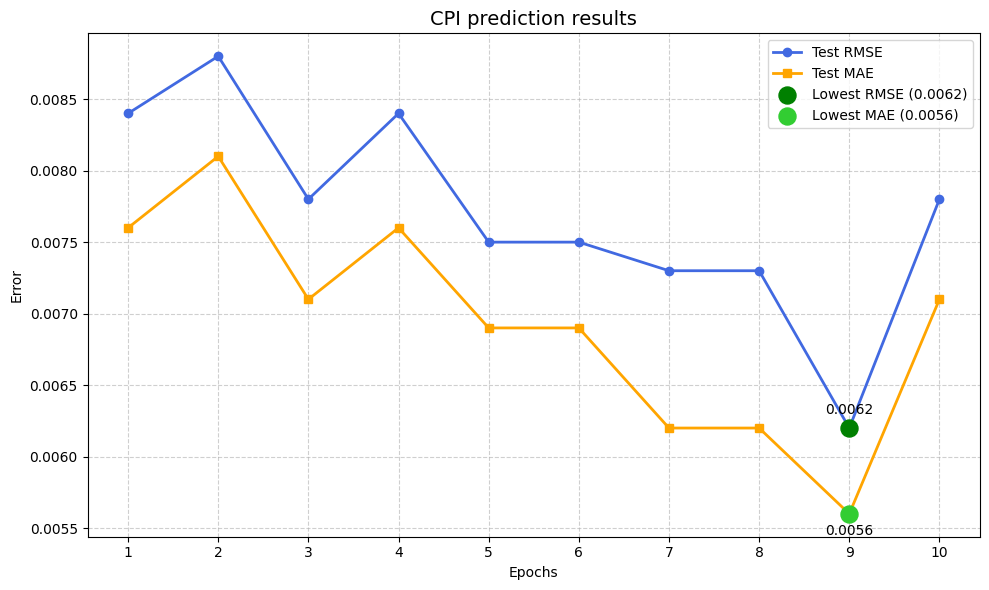

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Epochs
epochs = np.arange(1, 11)

rmse = [0.0084, 0.0088, 0.0078, 0.0084, 0.0075,
        0.0075, 0.0073, 0.0073, 0.0062, 0.0078]

mae = [0.0076, 0.0081, 0.0071, 0.0076, 0.0069,
       0.0069, 0.0062, 0.0062, 0.0056, 0.0071]

# Find minimum values
min_rmse_idx = np.argmin(rmse)
min_mae_idx = np.argmin(mae)

plt.figure(figsize=(10, 6))

# Plot lines
plt.plot(epochs, rmse, marker='o', linewidth=2,
         label='Test RMSE', color='royalblue')
plt.plot(epochs, mae, marker='s', linewidth=2,
         label='Test MAE', color='orange')

# Highlight minimum RMSE and MAE
plt.scatter(epochs[min_rmse_idx], rmse[min_rmse_idx],
            color='green', s=150, zorder=5,
            label=f'Lowest RMSE ({rmse[min_rmse_idx]:.4f})')

plt.scatter(epochs[min_mae_idx], mae[min_mae_idx],
            color='limegreen', s=150, zorder=5,
            label=f'Lowest MAE ({mae[min_mae_idx]:.4f})')

# Annotate minimum points
plt.annotate(f'{rmse[min_rmse_idx]:.4f}',
             (epochs[min_rmse_idx], rmse[min_rmse_idx]),
             xytext=(0, 10), textcoords='offset points',
             ha='center')

plt.annotate(f'{mae[min_mae_idx]:.4f}',
             (epochs[min_mae_idx], mae[min_mae_idx]),
             xytext=(0, -15), textcoords='offset points',
             ha='center')

plt.title('CPI prediction results',
          fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.xticks(epochs)  # Only whole numbers on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

### GDP

In [19]:
read_result = read_data_executor.invoke({"input":"D:/mycode/Fintech-agent/data/macro/gdp_dataset_agent.csv", "prompt":"predict GDP growth/rate"})   



> Entering new AgentExecutor chain...

Invoking: `read_data_tool` with `{'csv_path': 'D:/mycode/Fintech-agent/data/macro/gdp_dataset_agent.csv', 'prompt': ''}`


{'all_columns': ['date', 'b30ret', 'b20ret', 'b10ret', 'b7ret', 'b5ret', 'b2ret', 'b1ret', 't90ret', 't30ret', 'cpiret', 'wti_price', 'fedfunds', 'nfci', 'anfci', 'nfci_risk', 'nfci_credit', 'nfci_leverage', 'nfci_nonfinancial_leverage', 'gdp_growth', 'ppi', 'unrate', 'usd_index', 'trade_balance'], 'prompt': ''}Based on the output, I can classify each column into one of: 

- target: the single most appropriate column to predict
- feature: all other columns useful for prediction
- date: date/time identifier column (not useful as features

Here is the classification:

{
 "target": "gdp_growth",
 "feature_columns": ["b30ret", "b20ret", "b10ret", "b7ret", "b5ret", "b2ret", "b1ret", "t90ret", "t30ret", "cpiret", "wti_price", "fedfunds", "nfci", "anfci", "nfci_risk", "nfci_credit", "nfci_leverage", "nfci_nonfinancial_leverage", "p

In [ ]:
match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', read_result["output"], re.DOTALL)

<re.Match object; span=(486, 658), match='```\n{\n  "target": "caldt",\n  "feature_columns">


In [28]:
best_metrics, history = run_optimization_loop(
        csv_path = r"D:/mycode/Fintech-agent/data/macro/gdp_dataset_agent.csv",
        max_iter = 10,
        prompt = "prompt: predict GDP growth/rate",
        rag_docx_path = r"D:/mycode/Fintech-agent\Agentic System/rag_knowledge_base.docx"
    )

  RAG: 22 chunks loaded from knowledge base


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]



> Entering new AgentExecutor chain...

Invoking: `read_data_tool` with `{'csv_path': 'D:/mycode/Fintech-agent/data/macro/gdp_dataset_agent.csv', 'prompt': ''}`


{'all_columns': ['date', 'b30ret', 'b20ret', 'b10ret', 'b7ret', 'b5ret', 'b2ret', 'b1ret', 't90ret', 't30ret', 'cpiret', 'wti_price', 'fedfunds', 'nfci', 'anfci', 'nfci_risk', 'nfci_credit', 'nfci_leverage', 'nfci_nonfinancial_leverage', 'gdp_growth', 'ppi', 'unrate', 'usd_index', 'trade_balance'], 'prompt': ''}Based on the output, I can classify each column into one of: 

- target: the single most appropriate column to predict
- feature: all other columns useful for prediction
- date: date/time identifier column (not useful as features

Here is the classification:

{
 "target": "gdp_growth",
 "feature_columns": ["b30ret", "b20ret", "b10ret", "b7ret", "b5ret", "b2ret", "b1ret", "t90ret", "t30ret", "cpiret", "wti_price", "fedfunds", "nfci", "anfci", "nfci_risk", "nfci_credit", "nfci_leverage", "nfci_nonfinancial_leverage", "p

UnboundLocalError: cannot access local variable 'target' where it is not associated with a value

## volatility

## Report generation Agent

In [58]:
report_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a machine learning report generator.

Given evaluation metrics, generate a professional Markdown report including:

- Model Overview
- Performance Table
- Interpretation of metrics
- Overfitting Assessment
- Conclusion
"""
    ),
    ("human", "{input}")
])

report_chain = report_prompt | llm

In [59]:
if "shap_importance" in metrics:
    metrics["shap_importance"] = dict(
        sorted(metrics["shap_importance"].items(), key=lambda x: x[1], reverse=True))
    

# report_input = {
#     "history":      history,
#     "best_metrics": best_metrics,
#     "iterations":   len(history)
# }
# Step 3 — Generate report
report = report_chain.invoke(
    {"input": metrics} #best_metrics/report_input/metrics
)

print(report)

content="**Model Overview**\n================\n\nThe model used for this evaluation is a Gradient Boosting Regressor (GBR) with default configuration.\n\n**Performance Table**\n-------------------\n\n| Metric | Train | Test |\n| --- | --- | --- |\n| R2 Score | 0.955 | -0.264 |\n| RMSE | N/A | 0.0079 |\n| MAPE | N/A | 203.54 |\n\nNote: The test R2 score is negative, indicating that the model has overfit to the training data.\n\n**Interpretation of Metrics**\n---------------------------\n\n*   **R2 Score**: Measures the proportion of variance in the target variable explained by the model. A higher value indicates better fit.\n    *   Train R2 score: 0.955 (very good)\n    *   Test R2 score: -0.264 (poor, indicating overfitting)\n*   **RMSE (Root Mean Squared Error)**: Measures the average magnitude of the errors made by the model. A lower value indicates better performance.\n    *   Test RMSE: 0.0079\n*   **MAPE (Mean Absolute Percentage Error)**: Measures the average absolute percentage

In [5]:
with open("result/forecast_report.md", "w", encoding="utf-8") as f:
    f.write(report["content"])

print("Report saved to forecast_report.md")


Report saved to forecast_report.md


### References
https://docs.langchain.com/oss/python/integrations/chat/ollama

https://docs.langchain.com/oss/python/langchain/tools


- feed more data about the forecasting process and feature engineering information for better report
- purpose of the task (is it to understand how agentic system works or should we try to build an efficient system for real life scenario)
- should the tool be called by the agent 
